## Homework 4: Unsupervised Learning

### Exercise 1: Compute the SVD of a Matrix & Verify the Reconstruction

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def build_matrix(m=10, n=6, kind="structured", seed=0):
    """
    Construct a non-square matrix A in R^{m x n}.
    kind:
      - "random":     random Gaussian entries
      - "structured": low-rank + small noise (to see small singular values)
    """
    rng = np.random.default_rng(seed)

    if kind == "random":
        A = rng.normal(0, 1, size=(m, n))
        return A

    if kind == "structured":
        # low rank part: A0 = B C^T with rank r <= min(m,n)
        r = min(3, m, n)
        B = rng.normal(0, 1, size=(m, r))
        C = rng.normal(0, 1, size=(n, r))
        A0 = B @ C.T

        # add small noise so tiny singular values appear but not exact zeros
        noise = 1e-3 * rng.normal(0, 1, size=(m, n))
        A = A0 + noise
        return A
    
def compute_svd(A):
    """
    Full SVD: A = U Σ V^T
    numpy returns:
      U: (m, m) if full_matrices=True else (m, k)
      s: (k,) singular values
      Vt: (k, n)
    We'll use reduced SVD (full_matrices=False) to keep shapes simple.
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U, s, Vt

def reconstruct_from_svd(U, s, Vt):
    """
    Reconstruct A_hat = U Σ V^T
    with Σ formed from singular values s.
    """
    Sigma = np.diag(s)
    A_hat = U @ Sigma @ Vt
    return A_hat

def frobenius_error(A, A_hat):
    return np.linalg.norm(A - A_hat, ord="fro")

In [8]:
def plot_singular_values(s, title="Singular values"):
    for i, val in enumerate(s, start=1):
        print(f"  sigma_{i} = {val:.6e}")

    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(s) + 1), s, marker="o")
    plt.title(title)
    plt.xlabel("Index i")
    plt.ylabel("sigma_i")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

def run_ex1_svd(m=10, n=6, kind="structured", seed=0, show_matrix=False):
    A = build_matrix(m=m, n=n, kind=kind, seed=seed)

    if show_matrix:
        np.set_printoptions(precision=4, suppress=True)
        print("Matrix A:")
        print(A)
        print()

    U, s, Vt = compute_svd(A)
    A_hat = reconstruct_from_svd(U, s, Vt)
    errF = frobenius_error(A, A_hat)

    print("Shapes:")
    print(f"  A   : {A.shape}")
    print(f"  U   : {U.shape}")
    print(f"  s   : {s.shape}")
    print(f"  Vt  : {Vt.shape}")
    print()

    print("Reconstruction check:")
    print("  A ≈ U Σ V^T")
    print(f"  Frobenius error ||A - UΣV^T||_F = {errF:.6e}")
    print()

    plot_singular_values(s, title=f"Singular values (A: {m}x{n}, kind={kind})")

    return A, U, s, Vt, A_hat, errF

**Structured**

Shapes:
  A   : (10, 6)
  U   : (10, 6)
  s   : (6,)
  Vt  : (6, 6)

Reconstruction check:
  A ≈ U Σ V^T
  Frobenius error ||A - UΣV^T||_F = 4.055283e-15

  sigma_1 = 9.432252e+00
  sigma_2 = 4.174523e+00
  sigma_3 = 3.058116e+00
  sigma_4 = 3.246147e-03
  sigma_5 = 2.737904e-03
  sigma_6 = 2.171267e-03


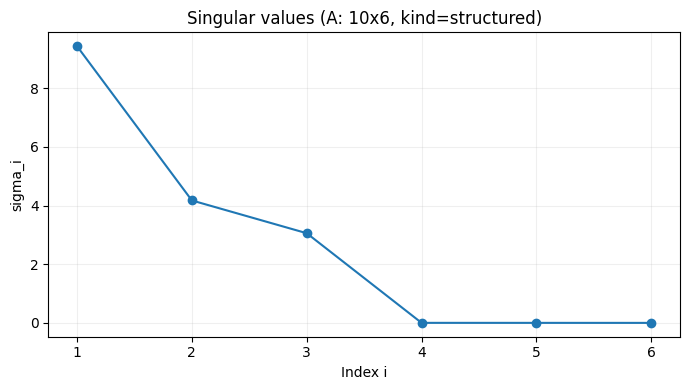

In [9]:
A, U, s, Vt, A_hat, errF = run_ex1_svd(m=10, n=6, kind="structured", seed=0)

**Random**

Shapes:
  A   : (10, 6)
  U   : (10, 6)
  s   : (6,)
  Vt  : (6, 6)

Reconstruction check:
  A ≈ U Σ V^T
  Frobenius error ||A - UΣV^T||_F = 7.244159e-15

  sigma_1 = 4.829108e+00
  sigma_2 = 3.423011e+00
  sigma_3 = 2.539353e+00
  sigma_4 = 2.011939e+00
  sigma_5 = 1.373909e+00
  sigma_6 = 1.123780e+00


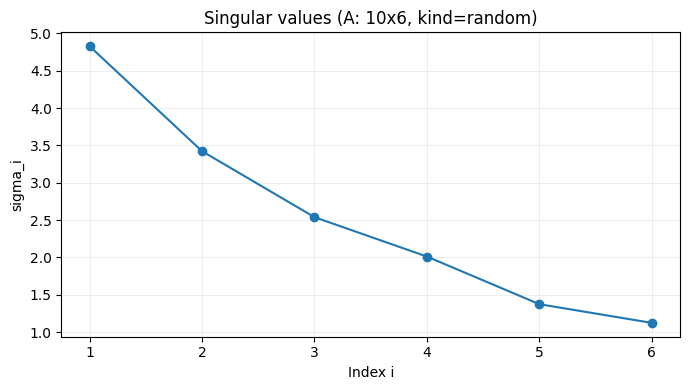

In [10]:
A, U, s, Vt, A_hat, errF = run_ex1_svd(m=10, n=6, kind="random", seed=0)